# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-7: Generador de Números Aleatorios Cuántico (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-7.

Los generadores de números pseudoaleatorios clásicos son deterministas: dado el mismo seed producen la misma secuencia. Un generador cuántico explota la naturaleza intrínsecamente probabilística de la medición cuántica para producir números verdaderamente aleatorios.

**Algoritmo:**
1. Calcular el número de qubits necesarios: $n = \lceil \log_2(\text{high} - \text{low}) \rceil$
2. Aplicar Hadamard a cada qubit → superposición uniforme sobre los $2^n$ estados base
3. Medir → colapsa a un estado base con probabilidad uniforme $1/2^n$
4. Convertir el resultado de bits a entero y mapear al rango `[low, high)`
5. Repetir descartando valores fuera del rango (rechazo) hasta obtener `m` números

El estado de superposición uniforme es:
$$|\psi\rangle = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle$$

### Erratas y diferencias de API corregidas

| Libro | Corrección | Motivo |
|---|---|---|
| `result.data.get_values()[0][0]` | `next(iter(result.histogram(key='z')))` | `get_values()` eliminado en pandas moderno |
| `while num_gen <= m` | `while num_gen < m` | `<= m` genera `m+1` números (off-by-one) |
| `m=10` en la firma, 21 en la salida | `m=20` | la salida del libro tiene 21 números, consistente con `<= 20` |

### Implementación

> **Nota de implementación:** el libro define una sola función `random_number_generator()`.
> Aquí se separa en `build_circuit()` y `random_number_generator()` únicamente para poder
> mostrar y visualizar el circuito en celdas independientes sin ejecutar el bucle de generación.

In [6]:
import cirq
import numpy as np


def build_circuit(low=0, high=2**10):
    """Construye el circuito de superposición uniforme para el rango [low, high)."""
    n = int(np.ceil(np.log2(high - low)))
    Q_reg = [cirq.LineQubit(i) for i in range(n)]
    circuit = cirq.Circuit()
    circuit.append(cirq.H(q) for q in Q_reg)
    circuit.append(cirq.measure(*Q_reg, key='z'))
    return circuit, n


def random_number_generator(low=0, high=2**10, m=20):
    """
    Genera m números enteros aleatorios en el rango [low, high) usando un circuito cuántico.

    low:  límite inferior (inclusive)
    high: límite superior (exclusive)
    m:    cantidad de números a generar
    """
    circuit, n = build_circuit(low, high)
    sim = cirq.Simulator()
    output = []

    while len(output) < m:
        result = sim.run(circuit, repetitions=1)
        # histogram devuelve un Counter; con repetitions=1 tiene exactamente un valor
        raw = next(iter(result.histogram(key='z')))
        rand_number = raw + low
        if rand_number < high:
            output.append(rand_number)

    return output

### Circuito (10 qubits, rango 0–1023)

In [7]:
circuit, n = build_circuit(low=0, high=2**10)
print(f"Qubits requeridos: {n}")
print(circuit)

Qubits requeridos: 10
0: ───H───M('z')───
          │
1: ───H───M────────
          │
2: ───H───M────────
          │
3: ───H───M────────
          │
4: ───H───M────────
          │
5: ───H───M────────
          │
6: ───H───M────────
          │
7: ───H───M────────
          │
8: ───H───M────────
          │
9: ───H───M────────


### Visualización del circuito

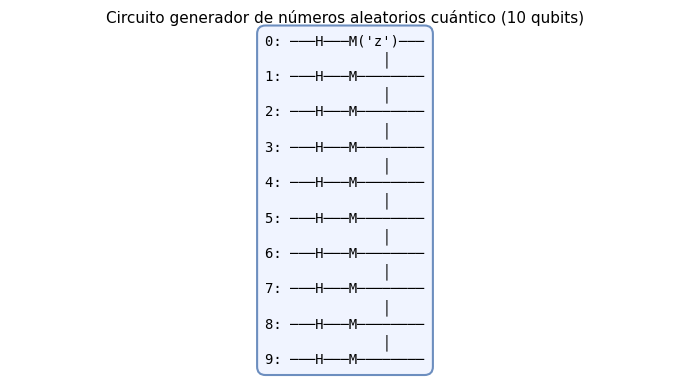

In [8]:
import matplotlib.pyplot as plt

diagrama = circuit.to_text_diagram()

fig, ax = plt.subplots(figsize=(7, 4))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=10,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Circuito generador de números aleatorios cuántico (10 qubits)', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Generación de números aleatorios

In [9]:
numeros = random_number_generator(low=0, high=2**10, m=20)

print("Números aleatorios generados:")
print(numeros)
print(f"\nMedia muestral: {np.mean(numeros):.2f}")
print(f"Media teórica (distribución uniforme 0–1023): {(0 + 1023) / 2:.2f}")

Números aleatorios generados:
[192, 69, 589, 416, 154, 10, 789, 477, 435, 489, 691, 776, 503, 328, 532, 964, 445, 254, 147, 689]

Media muestral: 447.45
Media teórica (distribución uniforme 0–1023): 511.50


### Distribución de los números generados

Con 20 muestras la distribución no es representativa. Generamos 200 para mostrar la uniformidad.

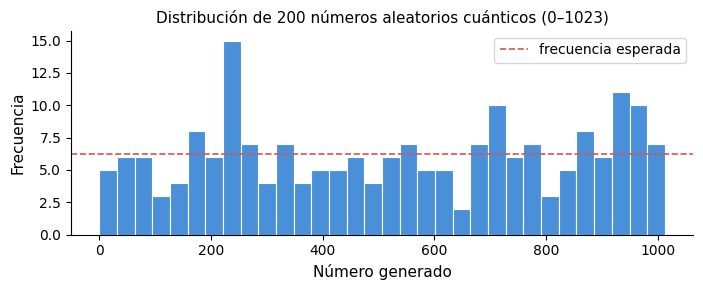

Media muestral (200 números): 528.69


In [10]:
muestra_grande = random_number_generator(low=0, high=2**10, m=200)

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(muestra_grande, bins=32, color='#4a90d9', edgecolor='white', linewidth=0.8)
ax.axhline(200 / 32, color='#d9534f', linestyle='--', linewidth=1.2, label='frecuencia esperada')
ax.set_xlabel('Número generado', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Distribución de 200 números aleatorios cuánticos (0–1023)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Media muestral (200 números): {np.mean(muestra_grande):.2f}")